In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(dplyr)
    library(SingleCellExperiment)
    library(ggpubr)
})

In [3]:
args = list() 
args$eomes_blood_meta = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping/sample_metadata_after_mapping.txt.gz'
args$atlas_meta = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata.txt.gz'

In [22]:
eomes_metadata <- fread(args$eomes_blood_meta)
atlas_metadata <- fread(args$atlas_meta)[,c('cell', 'stage')]

In [23]:
eomes_metadata = merge(eomes_metadata, atlas_metadata, by.x='closest.cell', by.y='cell')

In [24]:
head(eomes_metadata)

closest.cell,cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score,day_celltype,celltype_genotype,stage
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<chr>
cell_1000,1A_Eo_DEG_G9_day3#AGGTTTATCTTAGGGT-1,AGGTTTATCTTAGGGT-1,1A_Eo_DEG_G9_day3,3761,8698,4.66,7.38,day3_wt_rep1,D3,wt,TRUE,0.14,FALSE,Primitive_Streak,0.76,D3-wt,Primitive_Streak-wt,E7.5
cell_1000,1B_Eo_DEG_G9_day3#AGCTGCTCACCAACCG-1,AGCTGCTCACCAACCG-1,1B_Eo_DEG_G9_day3,3247,6579,3.56,6.34,day3_wt_rep2,D3,wt,TRUE,0.14,FALSE,Primitive_Streak,0.48,D3-wt,Primitive_Streak-wt,E7.5
cell_1000,2_Eo_DEG_G9_day3_5_VC#CAACCGGGTTGGATCA-1,CAACCGGGTTGGATCA-1,2_Eo_DEG_G9_day3_5_VC,3870,9785,12.01,9.28,day3.5_wt_rep2,D3.5,wt,TRUE,0.02,FALSE,Primitive_Streak,0.68,D3.5-wt,Primitive_Streak-wt,E7.5
cell_1000,2_Eo_DEG_G9_day3_5_VC#CGAACCGGTACAAAGA-1,CGAACCGGTACAAAGA-1,2_Eo_DEG_G9_day3_5_VC,3171,7483,15.84,8.43,day3.5_wt_rep2,D3.5,wt,TRUE,0.01,FALSE,Primitive_Streak,0.60,D3.5-wt,Primitive_Streak-wt,E7.5
cell_1000,2_Eo_DEG_G9_day3_5_VC#CTTCAAGCATTAGGTT-1,CTTCAAGCATTAGGTT-1,2_Eo_DEG_G9_day3_5_VC,3644,8871,10.68,8.61,day3.5_wt_rep2,D3.5,wt,TRUE,0.04,FALSE,Primitive_Streak,0.64,D3.5-wt,Primitive_Streak-wt,E7.5
cell_1000,2_Eo_DEG_G9_day3_5_VC#GAAGTATAGTTGCCTC-1,GAAGTATAGTTGCCTC-1,2_Eo_DEG_G9_day3_5_VC,5295,16420,10.81,6.38,day3.5_wt_rep2,D3.5,wt,TRUE,1.24,FALSE,Primitive_Streak,0.56,D3.5-wt,Primitive_Streak-wt,E7.5


In [43]:

stage.colors = c( "E6.5" = "#D53E4F",
                  "E6.75" = "#F46D43",
                  "E7.0" = "#FDAE61",
                  "E7.25" = "#FEE08B",
                  "E7.5" = "#FFFFBF",
                  "E7.75" = "#E6F598",
                  "E8.0" = "#ABDDA4",
                  "E8.25" = "#66C2A5",
                  "E8.5" = "#3288BD"
 )

In [38]:
props = eomes_metadata[,N_day:=.N, by='day'] %>% .[,prop_stage_day:=round(.N/N_day*100,2), by=c('day', 'stage')] %>% unique( by=c('day', 'stage'))

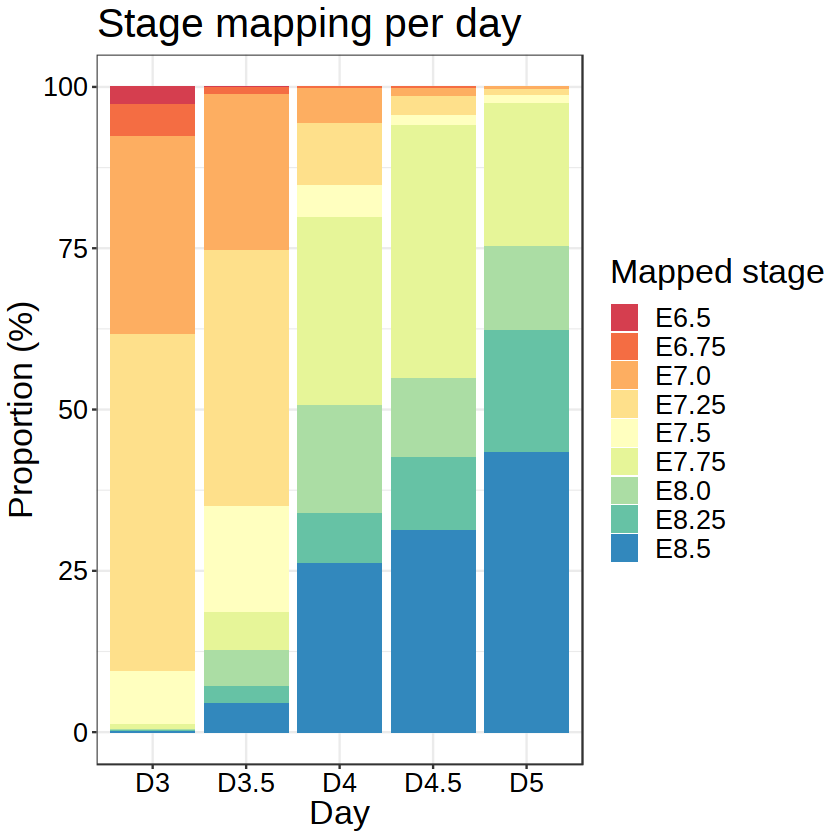

In [53]:
ggplot(props, aes(day, prop_stage_day, fill=stage)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=stage.colors, name='Mapped stage') + 
    theme_bw() + 
    xlab('Day') + ylab('Proportion (%)') + 
    ggtitle('Stage mapping per day') + 
    theme(text=element_text(size=20, color='black'),
         axis.text=element_text(color='black'))